In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOADING TRANSACTION DATASET

In [2]:
df= pd.read_csv(r"C:\Users\ns021\OneDrive\Documents\unified mentor project 1\Afficionado Coffee Roasters.xlsx - Transactions.csv")

In [3]:
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


DATA CLEANING

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   year              149116 non-null  int64  
 2   transaction_time  149116 non-null  str    
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  str    
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  str    
 9   product_type      149116 non-null  str    
 10  product_detail    149116 non-null  str    
dtypes: float64(1), int64(5), str(5)
memory usage: 12.5 MB


In [5]:
# Checking invalid time stamps
invalid_times=df['transaction_time'].isnull().sum()
print(f"Invalid timestamps:{invalid_times}")


Invalid timestamps:0


In [6]:
# CHECKING MISSING VALUES
missing_values=df.isnull().sum()
print(missing_values)

transaction_id      0
year                0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64


In [7]:
#CHECKING DUPLICATE TRANSACTIONS
duplicate_id=df.duplicated().sum()
print(f"Duplicate transaction ids:{duplicate_id}")

Duplicate transaction ids:0


In [8]:
# POSITIVE QUANTITIES
invalid_qty=(df['transaction_qty']<=0).sum()
print(f"Invalid quantities:{invalid_qty}")

Invalid quantities:0


In [9]:
# POSITIVE PRICES
invalid_price=(df['unit_price']<=0).sum()
print(f"Invalid prices:{invalid_price}")
df=df[df['unit_price']>0]

Invalid prices:0


FEATURE ENGINEERING (TEMPORAL)

In [10]:
# REVENUE PER TRANSACTION
df['revenue']=df['transaction_qty']* df['unit_price']
df.head()


,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


In [11]:
import pandas as pd
import numpy as np
# Convert transaction_time to datetime.time
if isinstance(df['transaction_time'].iloc[0],str):
    df['transaction_time'] = pd.to_datetime(df['transaction_time'], format= '%H:%M:%S').dt.time

# FUNCTION TO ASSIGN DATES WITHIN THE YEAR
def assign_dates(year,n):
    # Number of days in the year
    days_in_year=366 if pd.Timestamp(year=year,month=12,day=31).is_leap_year else 365
    # Repeat dates if n > days_in_year
    day_numbers=np.arange(n)%days_in_year
    return pd.to_datetime(f'{year}-01-01')+pd.to_timedelta(day_numbers,unit='D')

# ASSIGN DATES USING THE FUNCTION (ASSUMING ALL ROWS ARE FOR THE SAME YEAR,2025)
year = 2025
n = len(df)
df['date']=assign_dates(year,n)

# COMBINE WITH TRANSACTION_TIME
df['transaction_datetime'] = df.apply(
    lambda row: pd.Timestamp.combine(row['date'].date(),row['transaction_time']),
    axis=1
)

# EXTRACT HOUR(0-23)
df['hour']=df['transaction_datetime'].dt.hour

# EXTRACT DAY OF WEEK
df['day_of_week']=df['transaction_datetime'].dt.day_name()

# DROP INTERMEDIATE 'DATE' IF YOU WANT
df.drop(columns=['date'],inplace=True)

print(df.head())

   transaction_id  year transaction_time  transaction_qty  store_id  \
0               1  2025         07:06:11                2         5   
1               2  2025         07:08:56                2         5   
2               3  2025         07:14:04                2         5   
3               4  2025         07:20:24                1         5   
4               5  2025         07:22:41                2         5   

    store_location  product_id  unit_price    product_category  \
0  Lower Manhattan          32         3.0              Coffee   
1  Lower Manhattan          57         3.1                 Tea   
2  Lower Manhattan          59         4.5  Drinking Chocolate   
3  Lower Manhattan          22         2.0              Coffee   
4  Lower Manhattan          57         3.1                 Tea   

            product_type               product_detail  revenue  \
0  Gourmet brewed coffee                  Ethiopia Rg      6.0   
1        Brewed Chai tea     Spicy Eye Opene

In [12]:
# TIME BUCKETS
def get_time_bucket(hour):
    if 6 <=hour<=11:
        return 'Morning'
    elif 12<=hour<=16:
        return 'Afternoon'
    elif 17<=hour<=21:
        return 'Late Hours'

df['time_bucket']=df['hour'].apply(get_time_bucket)
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,transaction_datetime,hour,day_of_week,time_bucket
0,1,2025,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,2025-01-01 07:06:11,7,Wednesday,Morning
1,2,2025,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2025-01-02 07:08:56,7,Thursday,Morning
2,3,2025,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,2025-01-03 07:14:04,7,Friday,Morning
3,4,2025,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,2025-01-04 07:20:24,7,Saturday,Morning
4,5,2025,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2025-01-05 07:22:41,7,Sunday,Morning


SALES TREND ANALYSIS

In [13]:
# DAILY REVENUE TRENDS

# Daaily revenue aggregation using existing transaction_datetime
daily_revenue=df.groupby(df['transaction_datetime'].dt.date)['revenue'].sum()

daily_revenue.head()

transaction_datetime
2025-01-01    1860.50
2025-01-02    1951.53
2025-01-03    1928.38
2025-01-04    1917.38
2025-01-05    1873.47
Name: revenue, dtype: float64

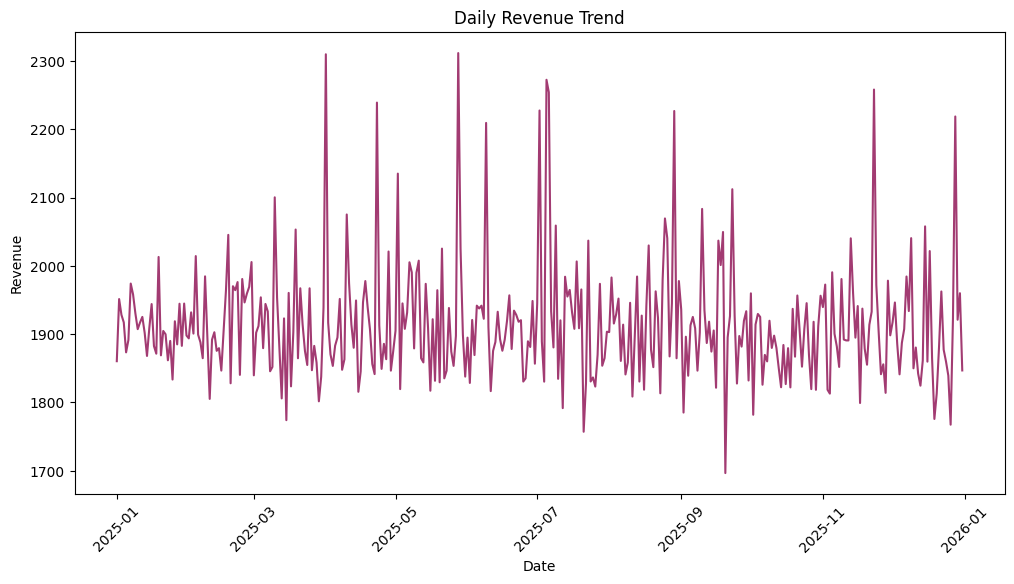

In [14]:
# Plot daily revenue trend

plt.figure(figsize=(12,6))
plt.plot(daily_revenue.index,daily_revenue.values,color='#A23B72')
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

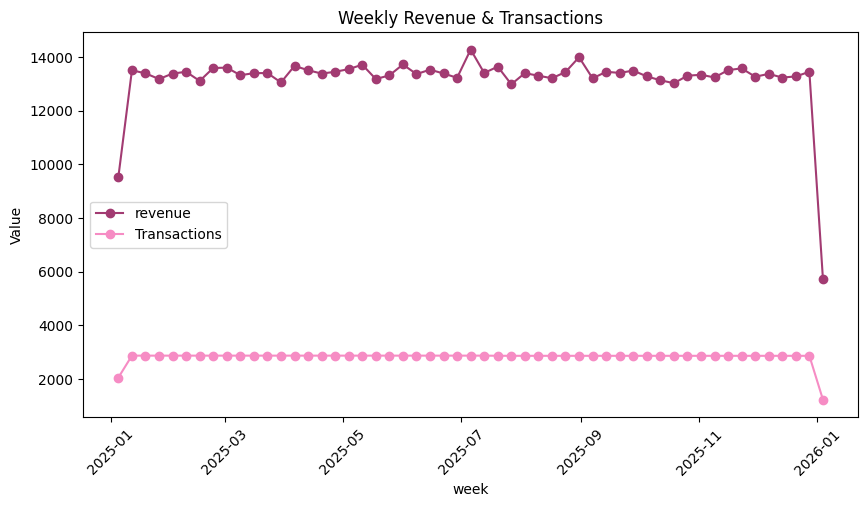

In [15]:
# Weekly Aggregation of revenue and transactions
weekly=df.set_index('transaction_datetime').resample('W').agg({
    'revenue':'sum',
    'transaction_id':'count'
})
plt.figure(figsize=(10,5))
plt.plot(weekly.index,weekly['revenue'],marker='o',label='revenue',color='#A23B72')
plt.plot(weekly.index,weekly['transaction_id'],marker='o',label='Transactions',color="#F68CC4")
plt.legend()
plt.title("Weekly Revenue & Transactions")
plt.xlabel("week")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show()

                      Weekly Revenue   Change
transaction_datetime                         
2025-01-05                   9531.26      NaN
2025-01-12                  13504.78  3973.52
2025-01-19                  13391.04  -113.74
2025-01-26                  13178.51  -212.53
2025-02-02                  13381.88   203.37


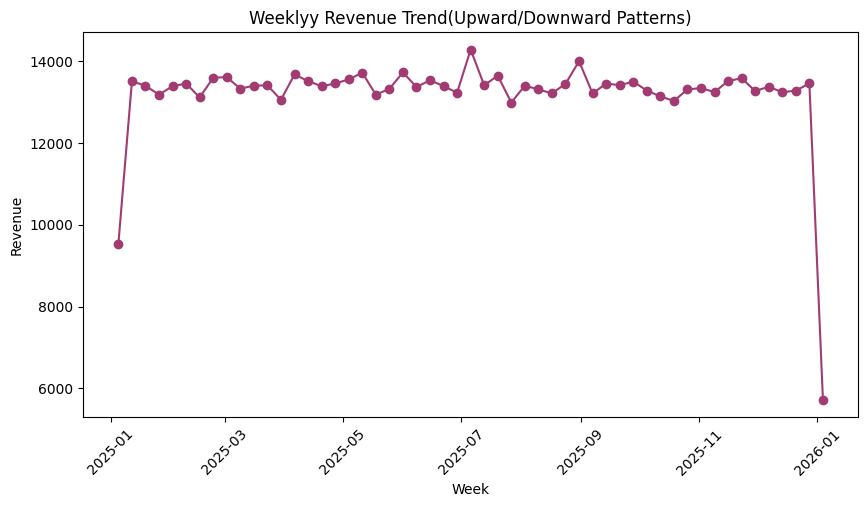

In [16]:
# Identification of upward/downward patterns

weekly_revenue=df.groupby(pd.Grouper(key='transaction_datetime',freq='W'))['revenue'].sum()

# Calculate change 
trend=weekly_revenue.diff()

trend_df=pd.DataFrame({
    "Weekly Revenue":weekly_revenue,
    "Change":trend
})

print(trend_df.head())

# Plot trend graph
plt.figure(figsize=(10,5))
plt.plot(trend_df.index,trend_df["Weekly Revenue"],marker='o',color='#A23B72')

plt.title("Weeklyy Revenue Trend(Upward/Downward Patterns)")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

store_location        Astoria  Hell's Kitchen  Lower Manhattan
transaction_datetime                                          
2025-01-05            3144.63         3038.10          3348.53
2025-01-12            4429.15         4284.25          4791.38
2025-01-19            4483.75         4814.05          4093.24
2025-01-26            4485.95         4088.80          4603.76
2025-02-02            4389.75         4446.48          4545.65


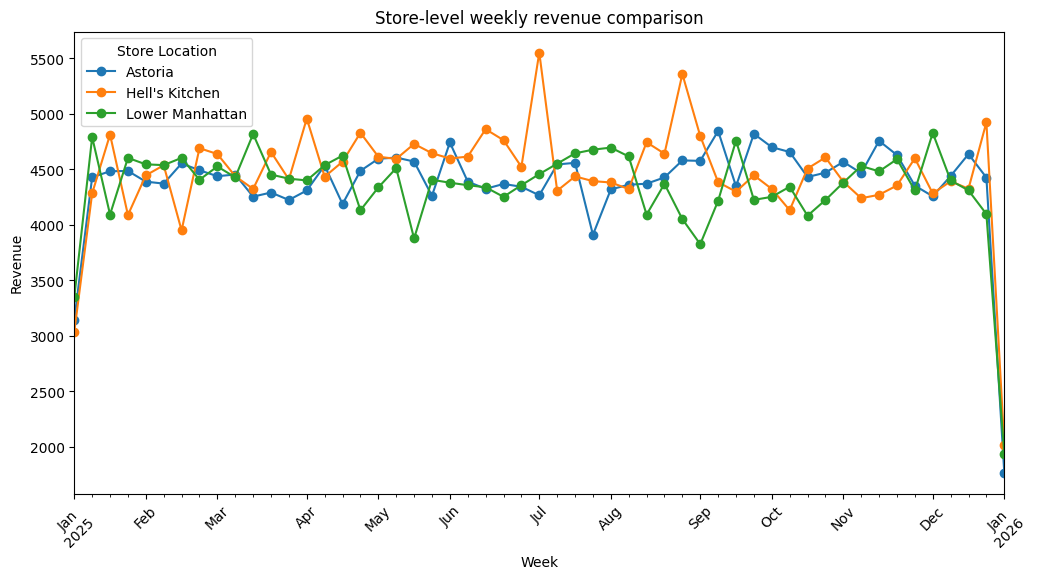

In [17]:
# Store-level trennd comparison
# Add 'date' column to the dataframe

store_trend=df.groupby(
    [pd.Grouper(key='transaction_datetime',freq='W'),'store_location']
)['revenue'].sum().unstack()

print(store_trend.head())

# Plot store comparison
store_trend.plot(figsize=(12,6),marker='o')

plt.title("Store-level weekly revenue comparison")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.legend(title="Store Location")
plt.show()

DAY OF WEEK PERFORMANCE ANALYSIS


Average revenue by day
day_of_week
Friday       4.673188
Monday       4.685256
Saturday     4.634654
Sunday       4.734050
Thursday     4.655987
Tuesday      4.692328
Wednesday    4.728302
Name: revenue, dtype: float64


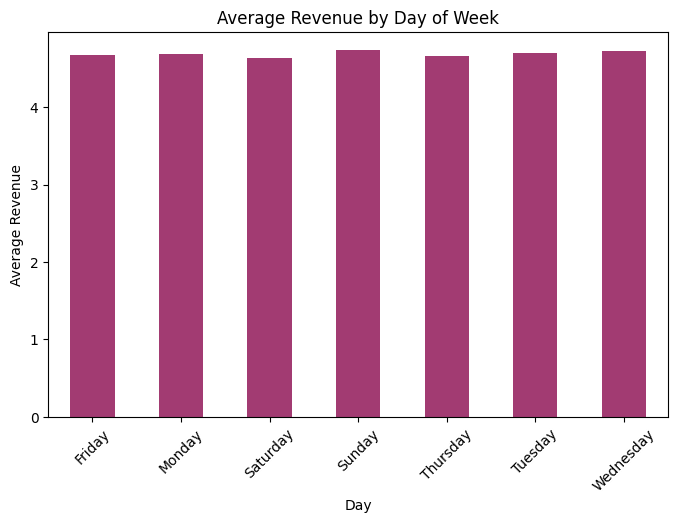

In [18]:
# Average revenue by day of week
avg_revenue=df.groupby('day_of_week')['revenue'].mean()

print("\nAverage revenue by day")
print(avg_revenue)

# PLOT
avg_revenue.plot(kind='bar',figsize=(8,5),color='#A23B72')
plt.title("Average Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.show()


Average Transactions by Day
day_of_week
Friday       21244
Monday       21244
Saturday     21244
Sunday       21244
Thursday     21244
Tuesday      21244
Wednesday    21652
Name: transaction_id, dtype: int64


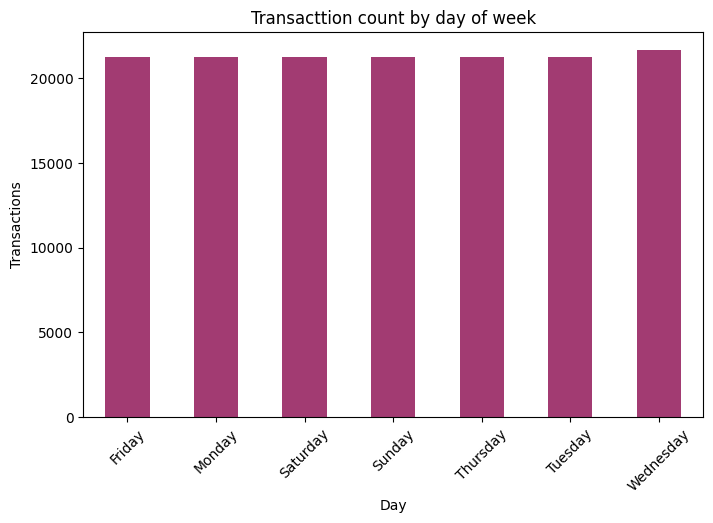

In [19]:
# Average transaction count by day
avg_transactions=df.groupby('day_of_week')['transaction_id'].count()
print("\nAverage Transactions by Day")
print(avg_transactions)

# PLOT
avg_transactions.plot(kind='bar',figsize=(8,5),color='#A23B72')
plt.title("Transacttion count by day of week")
plt.xlabel("Day")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.show()


Weekday vs Weekend Revenue
day_type
Weekday    4.687170
Weekend    4.684352
Name: revenue, dtype: float64


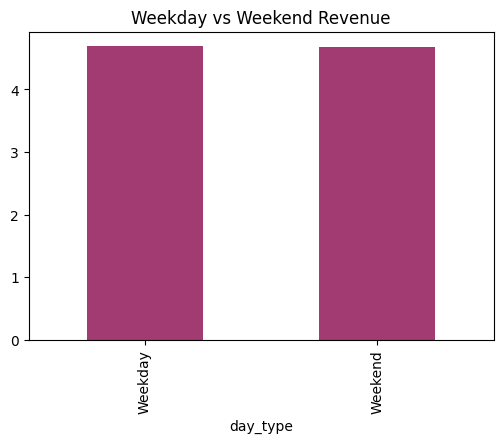

In [20]:
# Weekday vs weekendd comparison
df['day_type']=df['day_of_week'].apply(
    lambda x: 'Weekend' if x in ['Saturday','Sunday'] else 'Weekday'
)

weekday_weekend=df.groupby('day_type')['revenue'].mean()
print("\nWeekday vs Weekend Revenue")
print(weekday_weekend)

weekday_weekend.plot(kind='bar',figsize=(6,4),color='#A23B72')
plt.title("Weekday vs Weekend Revenue")
plt.show()


          total_revenue  avg_revenue  total_transactions  avg_quantity
day_type                                                              
Weekday       499783.59     4.687170              106628      1.437530
Weekend       199028.74     4.684352               42488      1.440148


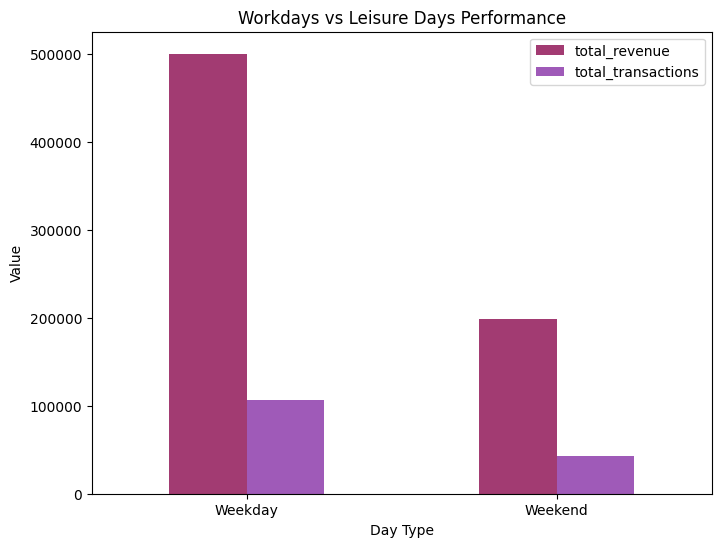

In [21]:
# Behaviour interpretation (workdays vs leisure days)

# Group analysis
behaviour_analysis=df.groupby('day_type').agg(
    total_revenue=('revenue','sum'),
    avg_revenue=('revenue','mean'),
    total_transactions=('transaction_id','count'),
    avg_quantity=('transaction_qty','mean')
)

print(behaviour_analysis)

# Visualization
behaviour_analysis[['total_revenue','total_transactions']].plot(kind='bar',figsize=(8,6),color=['#A23B72', "#9F5AB8"] )
plt.title("Workdays vs Leisure Days Performance")       
plt.xlabel("Day Type")                          
plt.ylabel("Value")  
plt.xticks(rotation=0) 
plt.show()          

TIME OF DAY DEMAND ANALYSIS

hour
6      4594
7     13428
8     17654
9     17764
10    18545
11     9766
12     8708
13     8714
14     8933
15     8979
16     9093
17     8745
18     7498
19     6092
20      603
Name: transaction_id, dtype: int64


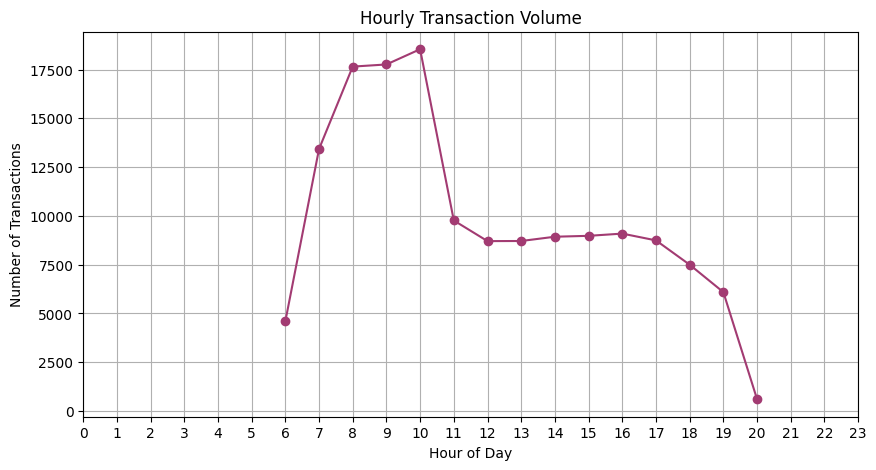

In [22]:
# Hourly Transaction volume
hourly_transactions=df.groupby('hour')['transaction_id'].count()
print(hourly_transactions)

plt.figure(figsize=(10,5))
plt.plot(hourly_transactions.index,hourly_transactions.values,marker='o',color='#A23B72')
plt.title("Hourly Transaction Volume")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

hour
6     21900.27
7     63526.47
8     82699.87
9     85169.53
10    88673.39
11    46319.14
12    40192.79
13    40367.45
14    41304.74
15    41733.10
16    41122.75
17    40134.31
18    34286.20
19    28446.68
20     2935.64
Name: revenue, dtype: float64


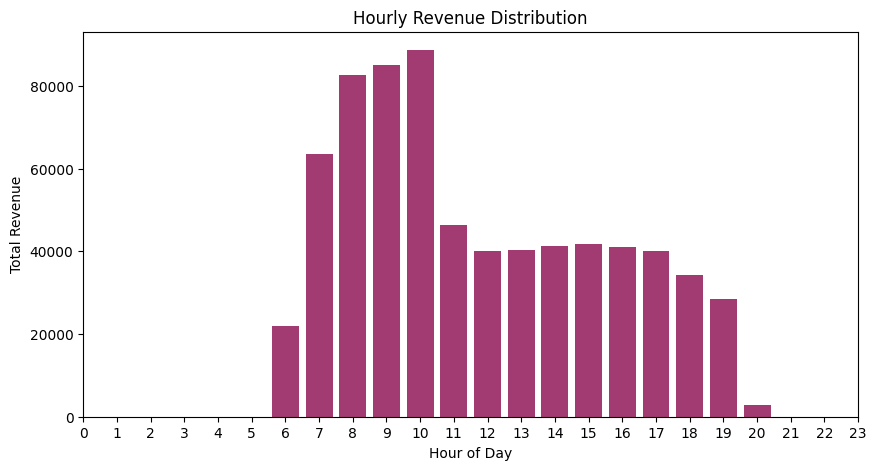

In [23]:
# Hourly Revenue Distribution
hourly_revenue=df.groupby('hour')['revenue'].sum()
print(hourly_revenue)
plt.figure(figsize=(10,5))
plt.bar(hourly_revenue.index,hourly_revenue.values,color='#A23B72')
plt.title("Hourly Revenue Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Total Revenue")
plt.xticks(range(0,24))
plt.show()

             total_transactions  total_revenue  avg_quantity
time_bucket                                                 
Afternoon                 44427      204720.83      1.436964
Late Hours                22938      105802.83      1.438704
Morning                   81751      388288.67      1.438869


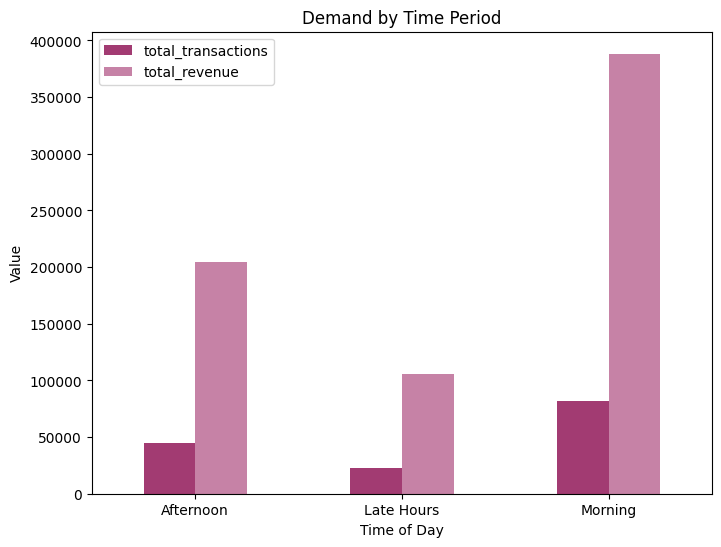

In [24]:
# Identification of morning rush hours,midday slow periods,evening peaks

time_analysis=df.groupby('time_bucket').agg(
    total_transactions=('transaction_id','count'),
    total_revenue=('revenue','sum'),
    avg_quantity=('transaction_qty','mean')
)
print(time_analysis)

time_analysis[['total_transactions','total_revenue']].plot(kind='bar',figsize=(8,6),color=('#A23B72',"#C682A6"))
plt.title("Demand by Time Period")
plt.xlabel("Time of Day")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.show()

CROSS-LOCATION TEMPORAL COMPARISON

hour                 6       7       8       9       10      11      12  \
store_location                                                            
Astoria             NaN  4181.0  4966.0  5083.0  5291.0  3413.0  3438.0   
Hell's Kitchen   1676.0  3455.0  6909.0  6767.0  6957.0  3598.0  2442.0   
Lower Manhattan  2918.0  5792.0  5779.0  5914.0  6297.0  2755.0  2828.0   

hour                 13      14      15      16      17      18      19     20  
store_location                                                                  
Astoria          3456.0  3319.0  3423.0  3599.0  3402.0  3463.0  3565.0    NaN  
Hell's Kitchen   2625.0  2754.0  2505.0  2691.0  2818.0  2608.0  2402.0  528.0  
Lower Manhattan  2633.0  2860.0  3051.0  2803.0  2525.0  1427.0   125.0   75.0  


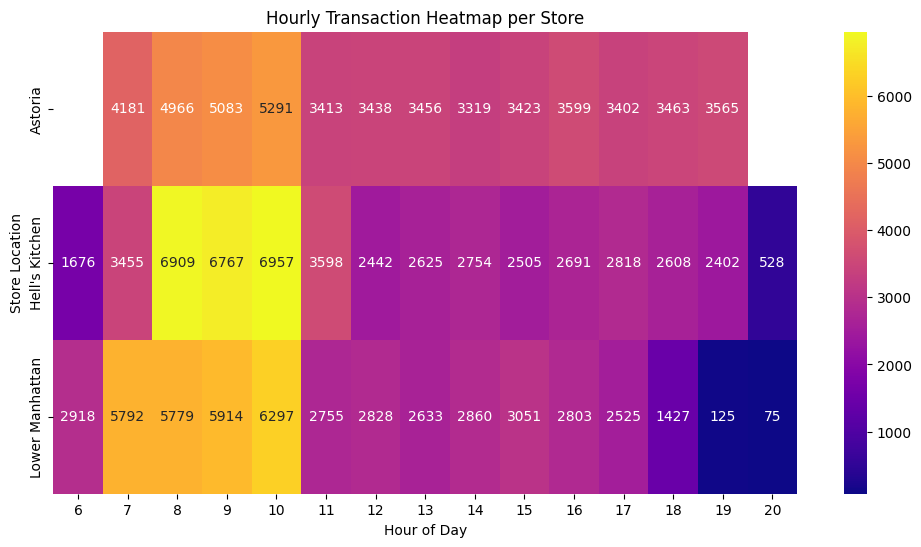

In [25]:
# Hourly heatmaps per store
# Create pivot table
heatmap_data=df.pivot_table(
    values='transaction_id',
    index='store_location',
    columns='hour',
    aggfunc='count'
)
print(heatmap_data)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data,cmap='plasma',annot=True,fmt=".0f")

plt.title("Hourly Transaction Heatmap per Store")
plt.xlabel('Hour of Day')
plt.ylabel("Store Location")
plt.show()

     store_location  hour  transaction_id
3           Astoria    10            5291
17   Hell's Kitchen    10            6957
32  Lower Manhattan    10            6297


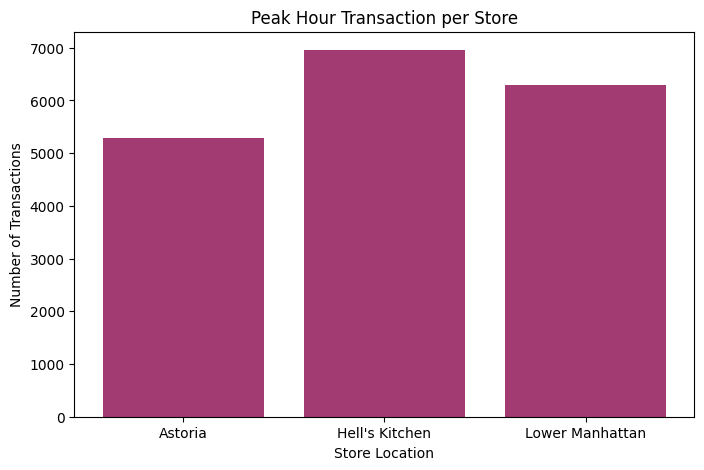

In [26]:
# Peak-Hour alignment or divergence across locations

# Group and find peak hours
peak_hours=df.groupby(['store_location','hour'])['transaction_id'].count().reset_index()

peak_per_store=peak_hours.loc[
    peak_hours.groupby('store_location')['transaction_id'].idxmax()
]

print(peak_per_store)

# Plot peak hours per store
plt.figure(figsize=(8,5))

plt.bar(
    peak_per_store['store_location'],
    peak_per_store['transaction_id'],
    color='#A23B72'
   
)

plt.title("Peak Hour Transaction per Store")
plt.xlabel("Store Location")
plt.ylabel("Number of Transactions")

plt.show()

                 total_transactions  total_revenue  avg_quantity
store_location                                                  
Astoria                       50599      232243.91      1.403012
Hell's Kitchen                50735      236511.17      1.413955
Lower Manhattan               47782      230057.25      1.501444


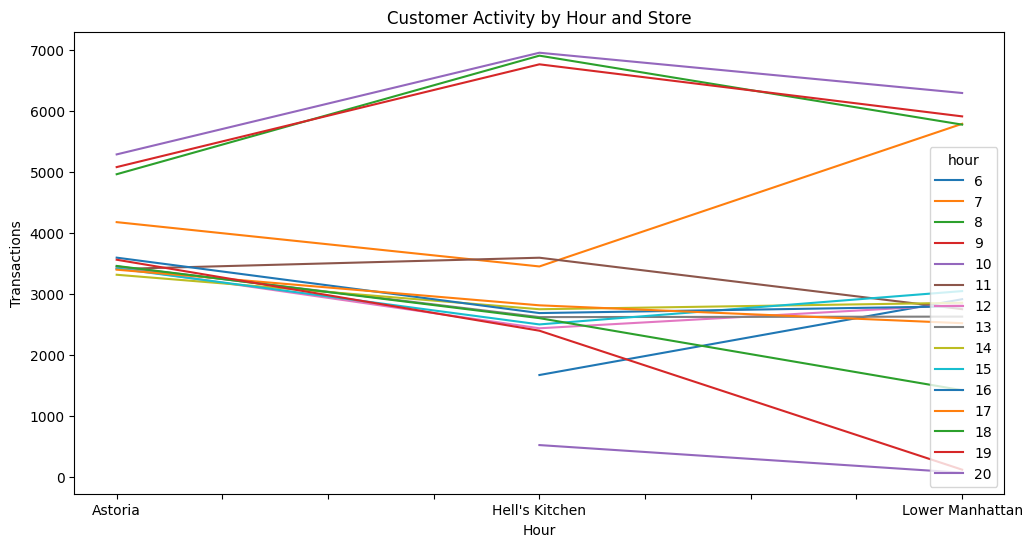

In [27]:
# Location specific customer behaviour insights
# Location-wise analysis
location_analysis=df.groupby('store_location').agg(
    total_transactions=('transaction_id','count'),
    total_revenue=('revenue','sum'),
    avg_quantity=('transaction_qty','mean')
)

print(location_analysis)
hourly_location=df.groupby(['store_location','hour'])['transaction_id'].count().unstack()

hourly_location.plot(figsize=(12,6))

plt.title("Customer Activity by Hour and Store")
plt.xlabel('Hour')
plt.ylabel("Transactions")

plt.show()

In [28]:
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,transaction_datetime,hour,day_of_week,time_bucket,day_type
0,1,2025,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,2025-01-01 07:06:11,7,Wednesday,Morning,Weekday
1,2,2025,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2025-01-02 07:08:56,7,Thursday,Morning,Weekday
2,3,2025,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,2025-01-03 07:14:04,7,Friday,Morning,Weekday
3,4,2025,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,2025-01-04 07:20:24,7,Saturday,Morning,Weekend
4,5,2025,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2025-01-05 07:22:41,7,Sunday,Morning,Weekend


In [29]:
df.to_csv('coffee_updated.csv',index=False)